# MECH 309: Assignment 3, Question 2

_Cagri Arslan_

February 15, 2025

*All work can be found on https://github.com/imported-canuck/MECH-309*

In [21]:
# Imports
from helpers import timed
from utils import *
import numpy as np
from scipy.linalg import eigh
from matplotlib import pyplot as plt

plt.style.use("bmh") # plotting style

### a) 
We compute the condition number of $\bold{A}$ (based on the induced 2-norm) by first seperating matrix $\bold{A}$ from vector $\bold{b}$, as `matrix_b.csv` provides the augmented matrix $\bold{[A|b]}$. We then use `np.linalg.cond(A, 2)` to determine the condition number. 

In [22]:
Ab = np.loadtxt("matrix_b.csv", delimiter=",")

A = Ab[:, :-1]      # first 3000 columns (drop the last column b)
b = Ab[:, -1]       # last column is the vector b

cond2 = float(np.linalg.cond(A, 2))
print(cond2)

49.997363468619795


A condition number of about 50 is not unexepected, and is fairly reasonable. It is actually quite low for a 3000 by 3000 matrix, and potentially implies that some sort of physical phenomenon (like a constant mass term that pushes the lowest eigenvalue away from 0) makes this operator well-behaved. 

### b)
A symmetric positive definite (SPD) matrix is a matrix that is symmetric **and** has all strictly positive eigenvalues. We can easily check if A is SPD by verifying these two conditions. It is done so below:


In [23]:
# Symmetry?
symmetric = np.allclose(A, A.T)
print("Is A symmetric?", symmetric)

# Positive definiteness?
eigenvalues = eigh(A, eigvals_only=True)
positive_definite = np.all(eigenvalues > 0)
print("Is A positive definite?", positive_definite)

# Conclude
if symmetric and positive_definite:
    print("A is symmetric positive definite (SPD).")

Is A symmetric? True
Is A positive definite? True
A is symmetric positive definite (SPD).


Indeed $\bold{A}$ is SPD. 

### c) 

Here we analyze the structural properties of $\bold{A}$. We compute the upper and lower bandwidths (how far above and below the main diagonal $\bold{A}$ has nonzero entries). Additionally, we plot the sparsity pattern of $\bold{A}$, showing that it is clearly pentadiagonal. Finally, we extract the nonzero diagonals (five of which exist for a pentadiagonal matrix) into 1D arrays.

Upper bandwidth: 2
Lower bandwidth: 2


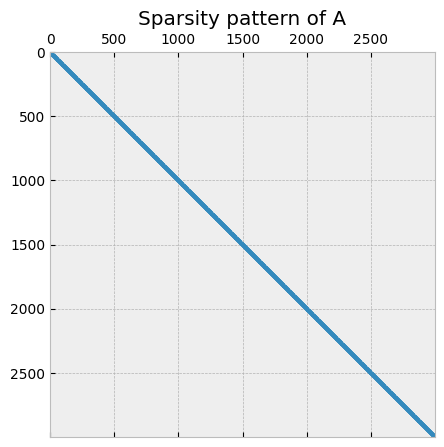

Nonzero diagonal offsets: [-2 -1  0  1  2]


In [24]:
# Compute bandwidths
rows, cols = np.nonzero(A)
offsets = cols - rows

# Compute upper and lower bandwidths
upper_bw = offsets.max()
lower_bw = (-offsets).max()

print("Upper bandwidth:", upper_bw)
print("Lower bandwidth:", lower_bw)


# Plot sparsity pattern
plt.figure(figsize=(5,5))
plt.spy(A, markersize=1)
plt.title("Sparsity pattern of A")
plt.show()


# Extrect nonzero diagonals
unique_offsets = np.unique(offsets)

diagonals = {}
for k in unique_offsets:
    diagonals[k] = np.diagonal(A, offset=k)

print("Nonzero diagonal offsets:", unique_offsets)

### d)

We now solve for $\bold{x}$ using a banded Cholesky factorization. The function to perform cholesky facotirzation on a pentadiagonal matrix is below. Note that it assumes that the input matrix $\bold{A}$ is pentadiagonal. In return, it can solve for $\bold{x}$ in $O(n)$ time and $O(n)$ space. 

In [25]:
def pentadiag_cholesky(A, b):
    '''
    Solves Ax = b for x, where A is an SPD pentadiagonal matrix, using a
    banded Cholesky factorization A = L L^T (storing only the main diagonal
    and the first two subdiagonals of L).

    Inputs:
        A (nparray): An (n, n) symmetric positive definite pentadiagonal matrix
        b (nparray): An (n,) or (n, 1) right-hand side vector

    Returns:
        x (nparray): The solution vector x as shape (n,)
    '''
    # Check input dimensions
    n = A.shape[0]
    
    if A.shape[1] != n:  # check if A is square
        raise ValueError("A must be square.")
    if b.shape[0] != n:  # check if b has compatible length
        raise ValueError("b must have length n.")

    b = np.asarray(b).reshape(-1)  # ensure shape (n,)

    # Extract the needed diagonals of A (just one side since A is symmetric)
    a0 = np.diagonal(A, 0)    # main diagonal, length n
    a1 = np.diagonal(A, -1)   # first subdiagonal, length n-1
    a2 = np.diagonal(A, -2)   # second subdiagonal, length n-2

    # Allocate storage for the 3 nonzero diagonals of L
    d0 = np.zeros(n)     # main diagonal of L
    d1 = np.zeros(n-1)   # first subdiagonal of L
    d2 = np.zeros(n-2)   # second subdiagonal of L

    # Banded Cholesky factorization: compute L such that A = L L^T
    d0[0] = np.sqrt(a0[0])

    # Initialize the i=1 case (recurrence needs previously computed entries)
    if n >= 2:
        d1[0] = a1[0] / d0[0]
        d0[1] = np.sqrt(a0[1] - d1[0]**2)

    # Compute the remaining entries of L using the pentadiagonal structure
    for i in range(2, n):
        d2[i-2] = a2[i-2] / d0[i-2]
        d1[i-1] = (a1[i-1] - d2[i-2]*d1[i-2]) / d0[i-1]
        d0[i]   = np.sqrt(a0[i] - d1[i-1]**2 - d2[i-2]**2)

    # Forward substitution: solve Ly = b
    y = np.zeros(n)
    y[0] = b[0] / d0[0]

    # Initialize the i=1 case (recurrence uses y[i-1] and y[i-2])
    if n >= 2:
        y[1] = (b[1] - d1[0]*y[0]) / d0[1]

    # Compute the remaining entries of y using the banded structure of L
    for i in range(2, n):
        y[i] = (b[i] - d1[i-1]*y[i-1] - d2[i-2]*y[i-2]) / d0[i]

    # Backward substitution: solve L^T x = y
    x = np.zeros(n)
    x[n-1] = y[n-1] / d0[n-1]

    # Initialize the i=n-2 case (recurrence uses x[i+1] and x[i+2])
    if n >= 2:
        x[n-2] = (y[n-2] - d1[n-2]*x[n-1]) / d0[n-2]

    # Compute the remaining entries of x using the banded structure of L^T
    for i in range(n-3, -1, -1):
        x[i] = (y[i] - d1[i]*x[i+1] - d2[i]*x[i+2]) / d0[i]

    return x


We now illustrate the advantage of a Cholesky factorization over a regular desnse solve by solving the system $\bold{Ax}=\bold{b}$ through the pentadiagonal Cholesky factorization and comparing its runtime with a regular dense solve through `np.linalg.solve`. 

In [26]:
@timed
def solve_banded(A, b):
    return pentadiag_cholesky(A, b)

@timed
def solve_numpy(A, b):
    return np.linalg.solve(A, b)

# Run both
x_band = solve_banded(A, b)
x_np   = solve_numpy(A, b)

# Compare solutions
diff = np.linalg.norm(x_band - x_np) / np.linalg.norm(x_np)
res_band = np.linalg.norm(A @ x_band - b) / np.linalg.norm(b)
res_np   = np.linalg.norm(A @ x_np   - b) / np.linalg.norm(b)

print("\n--- Accuracy checks ---")
print(f"Relative solution difference  ||x_band - x_np|| / ||x_np|| = {diff:.3e}")
print(f"Relative residual (banded)    ||Ax - b|| / ||b||        = {res_band:.3e}")
print(f"Relative residual (numpy)     ||Ax - b|| / ||b||        = {res_np:.3e}")


[solve_banded] elapsed time: 0.019188 s
[solve_numpy] elapsed time: 0.412359 s

--- Accuracy checks ---
Relative solution difference  ||x_band - x_np|| / ||x_np|| = 4.194e-16
Relative residual (banded)    ||Ax - b|| / ||b||        = 7.758e-16
Relative residual (numpy)     ||Ax - b|| / ||b||        = 6.696e-16


As can be seen by the outputs, the banded solve is almost 40 times faster than the regular dense solve. This highlights the benefit of exploting sparsity when possible. Mathematically, the banded Cholesky solve has a time complexity of $O(n)$, while the standard NumPy dense solve has a time complexity of $O(n^3)$. Thus, as matrix sizes continue to grow, this difference will be even more prounounced. 

### e)

A direct method (Cholesky) is robust, but for very large systems it can still be costly in memory/time.  

The Conjugate Gradient (CG) method is an iterative solver specialized for SPD matrices and uses only matrix–vector products, inner products, and vector updates.

Because $\bold{A}$ is pentadiagonal, each matrix–vector product can be computed in $O(n)$ time using only the three stored diagonals $(a0,a1,a2)$.

I implement CG with a stopping criterion based on the relative residual
$$
\frac{\|r_k\|_2}{\|b\|_2} \le \texttt{tol}.
$$
I report the iteration count and compare the solution against both `np.linalg.solve` and the banded Cholesky solution.


In [27]:
def cg_pentadiag(a0, a1, a2, b, x0=None, tol=1e-8, maxiter=None):
    '''
    Solves Ax = b for x using the Conjugate Gradient (CG) method, where A is an
    SPD symmetric pentadiagonal matrix stored via its diagonals.

    A has diagonals:
        a0: main diagonal, length n
        a1: first off-diagonal, length n-1  (used for both +1 and -1)
        a2: second off-diagonal, length n-2 (used for both +2 and -2)

    Inputs:
        a0 (nparray): Main diagonal of A, shape (n,)
        a1 (nparray): First off-diagonal of A, shape (n-1,)
        a2 (nparray): Second off-diagonal of A, shape (n-2,)
        b  (nparray): Right-hand side vector, shape (n,) or (n, 1)
        x0 (nparray): Optional initial guess, shape (n,) or (n, 1). If None, uses zeros.
        tol (float): Relative residual tolerance (stops when ||r||/||b|| <= tol)
        maxiter (int): Maximum number of iterations. If None, uses n.

    Returns:
        x (nparray): Approximate solution vector, shape (n,)
        iters (int): Number of CG iterations performed
        rel_res (float): Final relative residual norm ||r||/||b||
    '''
    b = np.asarray(b).reshape(-1)
    n = b.size
    if maxiter is None:
        maxiter = n
    if x0 is None:
        x = np.zeros(n)
    else:
        x = np.asarray(x0).reshape(-1).copy()

    a0 = np.asarray(a0).reshape(-1)
    a1 = np.asarray(a1).reshape(-1)
    a2 = np.asarray(a2).reshape(-1)

    if a0.size != n or a1.size != n-1 or a2.size != n-2:
        raise ValueError("Diagonal lengths must be: len(a0)=n, len(a1)=n-1, len(a2)=n-2.")

    def matvec(v):
        # Computes y = Av using the pentadiagonal structure (no dense A needed)
        y = a0 * v
        # Add contributions from the ±1 diagonals
        y[1:]  += a1 * v[:-1]
        y[:-1] += a1 * v[1:]
        # Add contributions from the ±2 diagonals
        y[2:]  += a2 * v[:-2]
        y[:-2] += a2 * v[2:]
        return y

    # Initialize residual r = b - A x and search direction p = r
    r = b - matvec(x)
    p = r.copy()
    rr = float(r @ r)

    # Compute ||b|| to form the stopping criterion ||r||/||b||
    bnorm = np.linalg.norm(b)
    if bnorm == 0:
        return x, 0, 0.0

    rel_res = np.sqrt(rr) / bnorm
    k = 0

    while rel_res > tol and k < maxiter:
        # Compute A p (needed for step length alpha)
        Ap = matvec(p)

        # Compute p^T A p (denominator in alpha)
        pAp = float(p @ Ap)
        if pAp <= 0:
            # Should not occur for SPD matrices; guard against numerical issues
            break

        # Step length: alpha = (r^T r) / (p^T A p)
        alpha = rr / pAp

        # Update solution: x_{k+1} = x_k + alpha p_k
        x = x + alpha * p

        # Update residual: r_{k+1} = r_k - alpha A p_k
        r = r - alpha * Ap

        # Compute new residual norm squared: r_{k+1}^T r_{k+1}
        rr_new = float(r @ r)

        # Direction update factor: beta = (r_{k+1}^T r_{k+1}) / (r_k^T r_k)
        beta = rr_new / rr

        # Update search direction: p_{k+1} = r_{k+1} + beta p_k
        p = r + beta * p

        # Update scalars for next iteration and recompute relative residual
        rr = rr_new
        rel_res = np.sqrt(rr) / bnorm
        k += 1

    return x, k, rel_res


We now compare the performance of the CG solver with the optimized banded solver, and the naive dense solver. 

In [28]:
# Extract diagonals from A (pentadiagonal SPD)
a0 = np.diagonal(A, 0)
a1 = np.diagonal(A, -1)
a2 = np.diagonal(A, -2)

# Timed wrappers
@timed
def solve_cg(a0, a1, a2, b, tol=1e-8, maxiter=None):
    return cg_pentadiag(a0, a1, a2, b, tol=tol, maxiter=maxiter)

@timed
def solve_banded(A, b):
    return pentadiag_cholesky(A, b)

@timed
def solve_numpy(A, b):
    return np.linalg.solve(A, b)

# Solve
x_cg, iters, relres = solve_cg(a0, a1, a2, b, tol=1e-8, maxiter=A.shape[0])
x_band = solve_banded(A, b)
x_np   = solve_numpy(A, b)

# Compare
rel_diff_cg_np   = np.linalg.norm(x_cg - x_np)   / np.linalg.norm(x_np)
rel_diff_band_np = np.linalg.norm(x_band - x_np) / np.linalg.norm(x_np)

rel_res_cg   = np.linalg.norm(A @ x_cg   - b) / np.linalg.norm(b)
rel_res_band = np.linalg.norm(A @ x_band - b) / np.linalg.norm(b)
rel_res_np   = np.linalg.norm(A @ x_np   - b) / np.linalg.norm(b)

print("\n--- CG results ---")
print(f"Iterations: {iters}")
print(f"Final CG relative residual (internal) ||r||/||b|| = {relres:.3e}")

print("\n--- Accuracy checks vs numpy.linalg.solve ---")
print(f"Rel diff (CG vs numpy)      ||x_cg - x_np||/||x_np||   = {rel_diff_cg_np:.3e}")
print(f"Rel diff (band vs numpy)    ||x_band - x_np||/||x_np|| = {rel_diff_band_np:.3e}")

print("\n--- Relative residuals ---")
print(f"CG      ||Ax-b||/||b|| = {rel_res_cg:.3e}")
print(f"Banded  ||Ax-b||/||b|| = {rel_res_band:.3e}")
print(f"Numpy   ||Ax-b||/||b|| = {rel_res_np:.3e}")


[solve_cg] elapsed time: 0.005448 s
[solve_banded] elapsed time: 0.013560 s
[solve_numpy] elapsed time: 0.404863 s

--- CG results ---
Iterations: 62
Final CG relative residual (internal) ||r||/||b|| = 8.669e-09

--- Accuracy checks vs numpy.linalg.solve ---
Rel diff (CG vs numpy)      ||x_cg - x_np||/||x_np||   = 6.297e-09
Rel diff (band vs numpy)    ||x_band - x_np||/||x_np|| = 4.194e-16

--- Relative residuals ---
CG      ||Ax-b||/||b|| = 8.669e-09
Banded  ||Ax-b||/||b|| = 7.758e-16
Numpy   ||Ax-b||/||b|| = 6.696e-16


As we can see, the Conjugate Gradient solver is faster than the banded Cholesky solver, without significantly increasing the residual. It is thus a useful iterative solution that can be used at scale, when extreme precision is not needeed. 

### f)

Now we implement a Jacobian preconditioner. Since the problem is already faily well-conditioned, incorporating a preconditioner only provides incremental benefit. However, it should still reduce the number of CG steps until convergence, and consequently reduce the runtime of the program. 



In [29]:
def pcg_jacobi_pentadiag(a0, a1, a2, b, x0=None, tol=1e-8, maxiter=None):
    '''
    Solves Ax = b for x using the Preconditioned Conjugate Gradient (PCG) method,
    where A is an SPD symmetric pentadiagonal matrix stored via its diagonals.
    The preconditioner used is Jacobi (diagonal) preconditioning: M = diag(A).

    A has diagonals:
        a0: main diagonal, length n
        a1: first off-diagonal, length n-1  (used for both +1 and -1)
        a2: second off-diagonal, length n-2 (used for both +2 and -2)

    Preconditioner:
        M = diag(A) = a0  =>  z = M^{-1} r computed elementwise as z_i = r_i / a0_i

    Inputs:
        a0 (nparray): Main diagonal of A, shape (n,)
        a1 (nparray): First off-diagonal of A, shape (n-1,)
        a2 (nparray): Second off-diagonal of A, shape (n-2,)
        b  (nparray): Right-hand side vector, shape (n,) or (n, 1)
        x0 (nparray): Optional initial guess, shape (n,) or (n, 1). If None, uses zeros.
        tol (float): Relative residual tolerance (stops when ||r||/||b|| <= tol)
        maxiter (int): Maximum number of iterations. If None, uses n.

    Returns:
        x (nparray): Approximate solution vector, shape (n,)
        iters (int): Number of PCG iterations performed
        rel_res (float): Final relative residual norm ||r||/||b|| (unpreconditioned residual)
    '''
    b = np.asarray(b).reshape(-1)
    n = b.size
    if maxiter is None:
        maxiter = n
    if x0 is None:
        x = np.zeros(n)
    else:
        x = np.asarray(x0).reshape(-1).copy()

    a0 = np.asarray(a0).reshape(-1)
    a1 = np.asarray(a1).reshape(-1)
    a2 = np.asarray(a2).reshape(-1)

    if a0.size != n or a1.size != n-1 or a2.size != n-2:
        raise ValueError("Diagonal lengths must be: len(a0)=n, len(a1)=n-1, len(a2)=n-2.")
    if np.any(a0 == 0):
        raise ValueError("Jacobi preconditioner requires all diagonal entries a0 to be nonzero.")

    def matvec(v):
        # Computes y = A v using the pentadiagonal structure (no dense A needed)
        y = a0 * v
        # Add contributions from the ±1 diagonals
        y[1:]  += a1 * v[:-1]
        y[:-1] += a1 * v[1:]
        # Add contributions from the ±2 diagonals
        y[2:]  += a2 * v[:-2]
        y[:-2] += a2 * v[2:]
        return y

    def apply_Minv(r):
        # Applies the Jacobi preconditioner: z = M^{-1} r with M = diag(A) = a0
        return r / a0

    # Initialize residual r = b - A x, then apply preconditioner z = M^{-1} r
    r = b - matvec(x)
    z = apply_Minv(r)

    # Initialize search direction p = z
    p = z.copy()

    # Store r^T z (the PCG analogue of r^T r)
    rz = float(r @ z)

    # Compute ||b|| to form the stopping criterion ||r||/||b||
    bnorm = np.linalg.norm(b)
    if bnorm == 0:
        return x, 0, 0.0

    rel_res = np.linalg.norm(r) / bnorm
    k = 0

    while rel_res > tol and k < maxiter:
        # Compute A p (needed for step length alpha)
        Ap = matvec(p)

        # Compute p^T A p (denominator in alpha)
        pAp = float(p @ Ap)
        if pAp <= 0:
            # Should not occur for SPD matrices; guard against numerical issues
            break

        # Step length: alpha = (r^T z) / (p^T A p)
        alpha = rz / pAp

        # Update solution: x_{k+1} = x_k + alpha p_k
        x = x + alpha * p

        # Update residual: r_{k+1} = r_k - alpha A p_k
        r = r - alpha * Ap

        # Update and check relative residual using the (unpreconditioned) residual r
        rel_res = np.linalg.norm(r) / bnorm
        if rel_res <= tol:
            k += 1
            break

        # Apply preconditioner: z_{k+1} = M^{-1} r_{k+1}
        z = apply_Minv(r)

        # Update scalar r^T z and compute beta
        rz_new = float(r @ z)
        beta = rz_new / rz

        # Update search direction: p_{k+1} = z_{k+1} + beta p_k
        p = z + beta * p

        # Prepare for next iteration
        rz = rz_new
        k += 1

    return x, k, rel_res


We now compare the performance of the preconditioned CG solver with the regular CG solver, the optimized banded solver, and the naive dense solver. 

In [30]:
# Extract diagonals from A
a0 = np.diagonal(A, 0)
a1 = np.diagonal(A, -1)
a2 = np.diagonal(A, -2)

@timed
def solve_pcg(a0, a1, a2, b, tol=1e-8, maxiter=None):
    return pcg_jacobi_pentadiag(a0, a1, a2, b, tol=tol, maxiter=maxiter)

@timed
def solve_cg(a0, a1, a2, b, tol=1e-8, maxiter=None):
    return cg_pentadiag(a0, a1, a2, b, tol=tol, maxiter=maxiter)

@timed
def solve_banded(A, b):
    return pentadiag_cholesky(A, b)

@timed
def solve_numpy(A, b):
    return np.linalg.solve(A, b)

# Solve
x_pcg, it_pcg, rr_pcg = solve_pcg(a0, a1, a2, b, tol=1e-8, maxiter=A.shape[0])
x_cg,  it_cg,  rr_cg  = solve_cg(a0, a1, a2, b, tol=1e-8, maxiter=A.shape[0])
x_band = solve_banded(A, b)
x_np   = solve_numpy(A, b)

# Compare to numpy solution
rel_diff_pcg = np.linalg.norm(x_pcg - x_np) / np.linalg.norm(x_np)
rel_diff_cg  = np.linalg.norm(x_cg  - x_np) / np.linalg.norm(x_np)

rel_res_pcg = np.linalg.norm(A @ x_pcg - b) / np.linalg.norm(b)
rel_res_cg  = np.linalg.norm(A @ x_cg  - b) / np.linalg.norm(b)

print("\n--- Iterations ---")
print(f"CG iterations:  {it_cg},  final ||r||/||b|| = {rr_cg:.3e}")
print(f"PCG iterations: {it_pcg}, final ||r||/||b|| = {rr_pcg:.3e}")

print("\n--- Accuracy vs numpy.linalg.solve ---")
print(f"Rel diff (CG  vs numpy)  = {rel_diff_cg:.3e}")
print(f"Rel diff (PCG vs numpy)  = {rel_diff_pcg:.3e}")

print("\n--- Relative residuals (true) ---")
print(f"CG   ||Ax-b||/||b|| = {rel_res_cg:.3e}")
print(f"PCG  ||Ax-b||/||b|| = {rel_res_pcg:.3e}")


[solve_pcg] elapsed time: 0.004415 s
[solve_cg] elapsed time: 0.004881 s
[solve_banded] elapsed time: 0.010898 s
[solve_numpy] elapsed time: 0.390663 s

--- Iterations ---
CG iterations:  62,  final ||r||/||b|| = 8.669e-09
PCG iterations: 44, final ||r||/||b|| = 7.192e-09

--- Accuracy vs numpy.linalg.solve ---
Rel diff (CG  vs numpy)  = 6.297e-09
Rel diff (PCG vs numpy)  = 4.762e-09

--- Relative residuals (true) ---
CG   ||Ax-b||/||b|| = 8.669e-09
PCG  ||Ax-b||/||b|| = 7.192e-09


Preconditioning has indeed reduced the number of CG iterations, albeit by a fairly modest amount, due to the fact that the problem was already decently well-conditioned. Nevertheless, it is a useful tool to "cheaply" reduce the number of CG iterations and speed up convergence, especially for poorly-conditioned matrices. 